# Entropy–Performance Coupling (Lag Analysis)

Goal: test whether entropy loss changes precede performance changes.

Expected takeaway: leading/lagging relationship between exploration and accuracy.


In [1]:
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Robust data directory resolver (works from repo root or final_results/tools)

def get_data_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = []
    for parent in [cwd] + list(cwd.parents):
        candidates.append(parent / "final_results" / "data")
        candidates.append(parent / "data")
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError(f"Could not locate data directory in candidates: {candidates}")

DATA_DIR = get_data_dir()

combined = pd.read_csv(DATA_DIR / "combined_wide.csv")
combined = combined.drop(columns=[c for c in combined.columns if c.lower().startswith("unnamed")], errors="ignore")
combined["Step"] = pd.to_numeric(combined["Step"], errors="coerce")
combined["seed"] = combined["seed"].astype(str)

metric_cols = ["avg@32", "pass@1", "pass@2", "pass@4", "pass@8", "pass@16", "pass@32", "pass@64", "pass@128"]
for c in metric_cols:
    combined[c] = pd.to_numeric(combined[c], errors="coerce")

passk_cols = [c for c in metric_cols if c.startswith("pass@")]
passk_ks = [int(c.split("@")[1]) for c in passk_cols]

final_step = int(combined["Step"].max())

# Aggregate across seeds for smoother curves
agg = combined.groupby(["Step", "algorithm"], as_index=False)[metric_cols].mean()

ent = pd.read_csv(DATA_DIR / "entropyloss_wide.csv")
ent["Step"] = pd.to_numeric(ent["Step"], errors="coerce")
ent["seed"] = ent["seed"].astype(str)
ent["actor/entropy_loss"] = pd.to_numeric(ent["actor/entropy_loss"], errors="coerce")

ent_agg = ent.groupby(["Step", "algorithm"], as_index=False)["actor/entropy_loss"].mean()

PLOT_COUNTER = 0

def new_fig(title: str):
    global PLOT_COUNTER
    PLOT_COUNTER += 1
    plt.figure()
    plt.title(title)


In [2]:
# Merge entropy and performance
merged = pd.merge(agg, ent_agg, on=["Step", "algorithm"], how="inner")
metrics = ["pass@1", "pass@8", "pass@32"]

# Compute lag correlation per algorithm
lags = [-4, -2, 0, 2, 4]
records = []
for algo in merged["algorithm"].unique():
    sub = merged[merged["algorithm"] == algo].sort_values("Step")
    for metric in metrics:
        for lag in lags:
            x = sub["actor/entropy_loss"].values
            y = sub[metric].values
            if lag < 0:
                corr = np.corrcoef(x[-lag:], y[:lag])[0,1] if len(x) > abs(lag) else np.nan
            elif lag > 0:
                corr = np.corrcoef(x[:-lag], y[lag:])[0,1] if len(x) > lag else np.nan
            else:
                corr = np.corrcoef(x, y)[0,1] if len(x) > 1 else np.nan
            records.append({"algorithm": algo, "metric": metric, "lag": lag, "corr": corr})

lagcorr = pd.DataFrame(records)


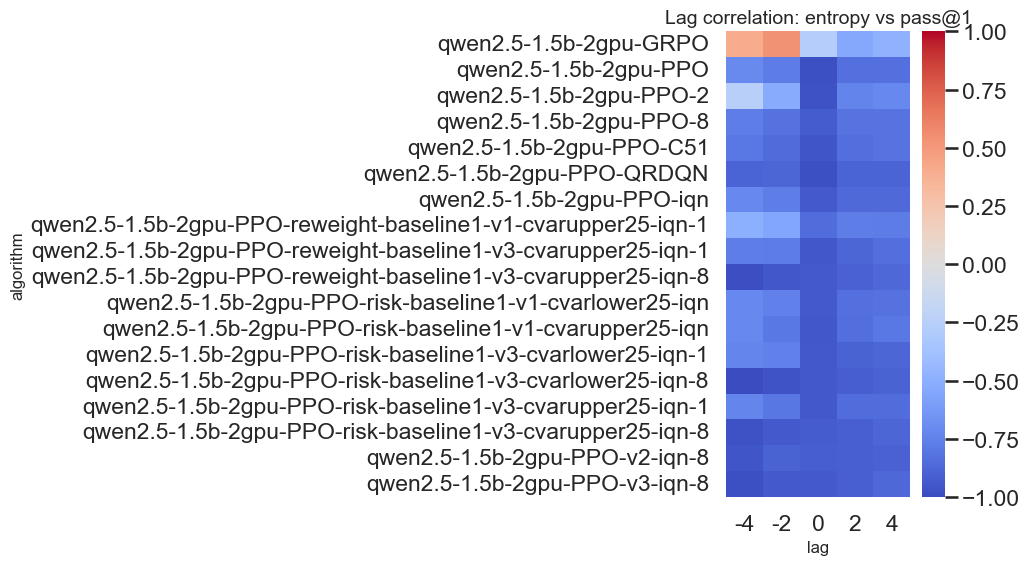

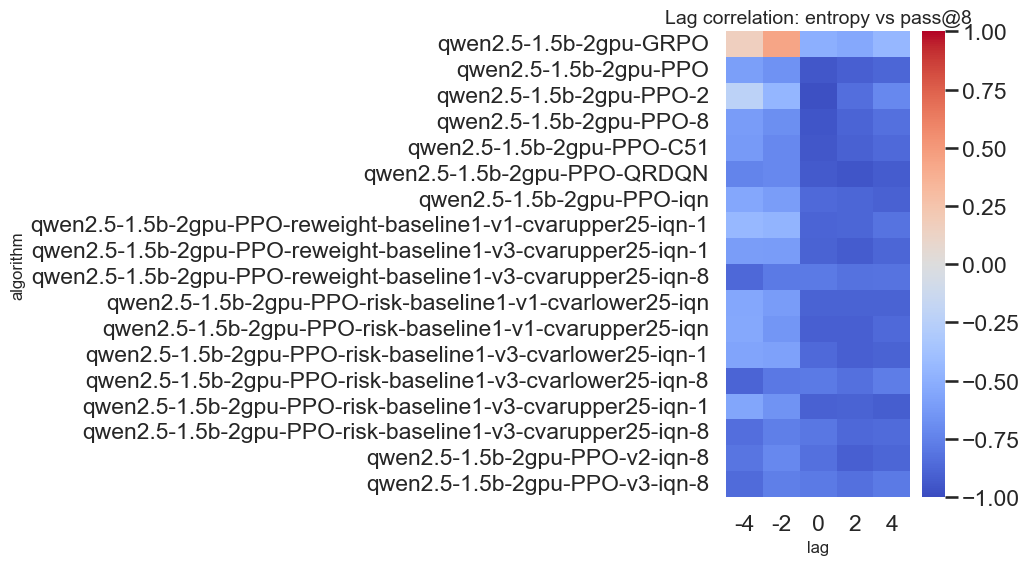

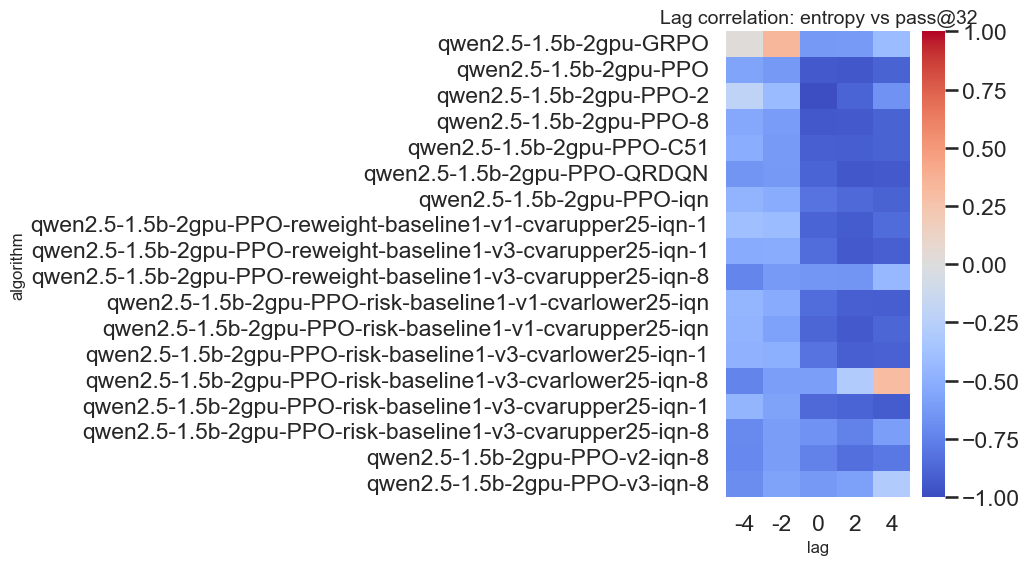

In [3]:
# Plot 1: heatmap of lag correlations (per metric)
for metric in metrics:
    pivot = lagcorr[lagcorr["metric"] == metric].pivot(index="algorithm", columns="lag", values="corr")
    new_fig(f"Lag correlation: entropy vs {metric}")
    sns.heatmap(pivot, cmap="coolwarm", vmin=-1, vmax=1)
    plt.tight_layout()
    plt.show()


/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_95997/2588537124.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


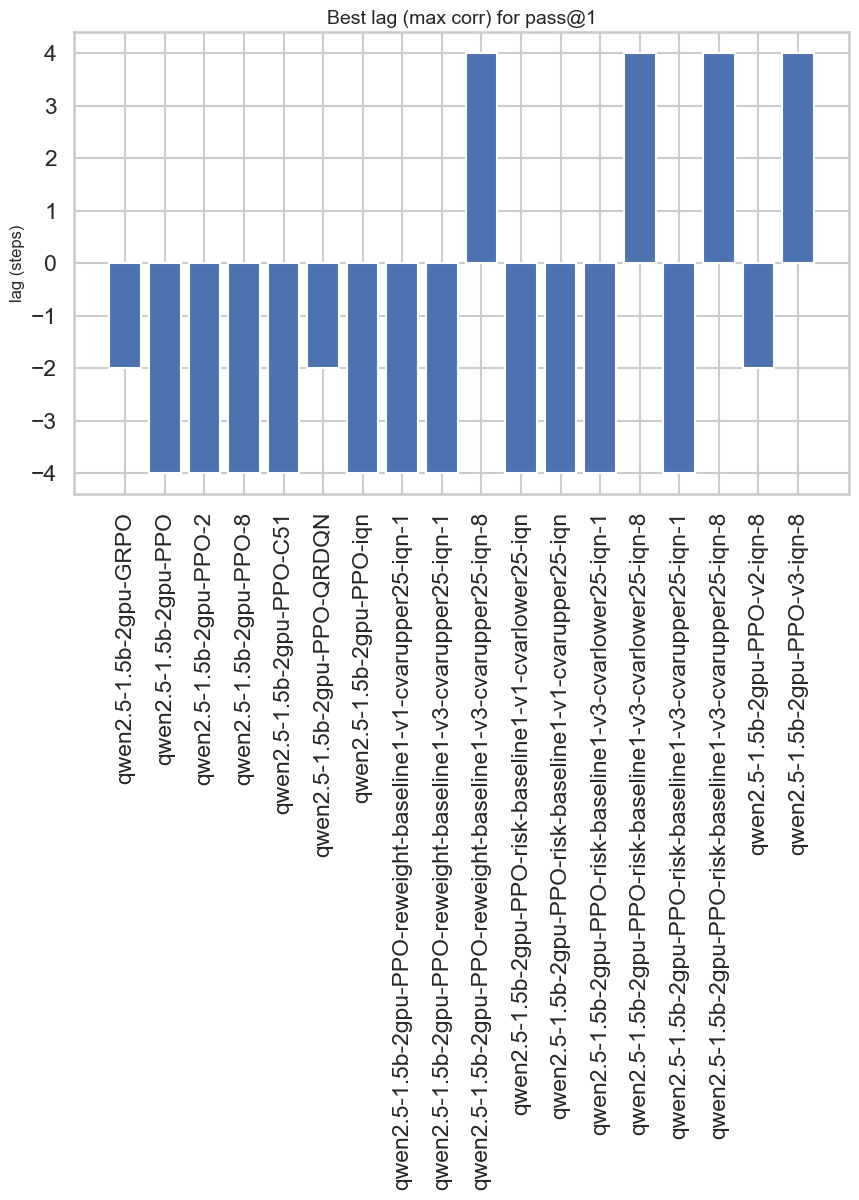

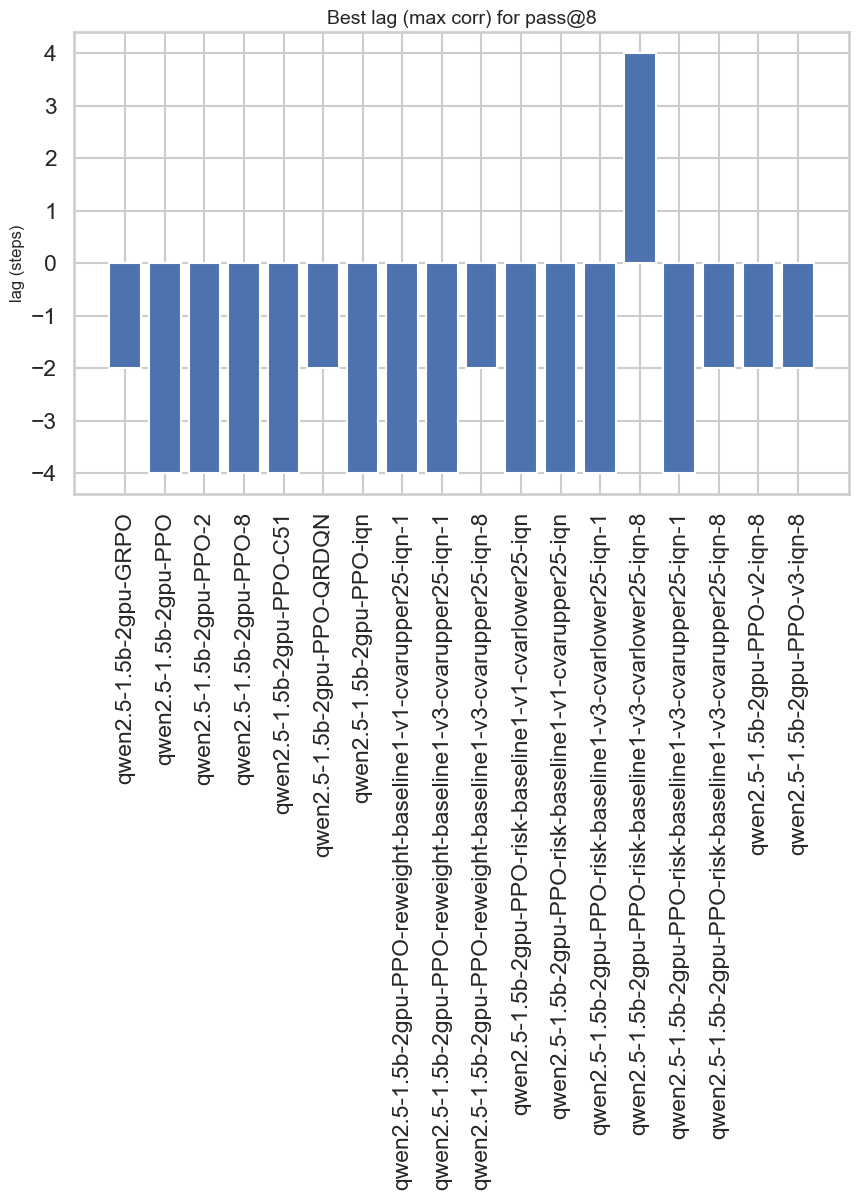

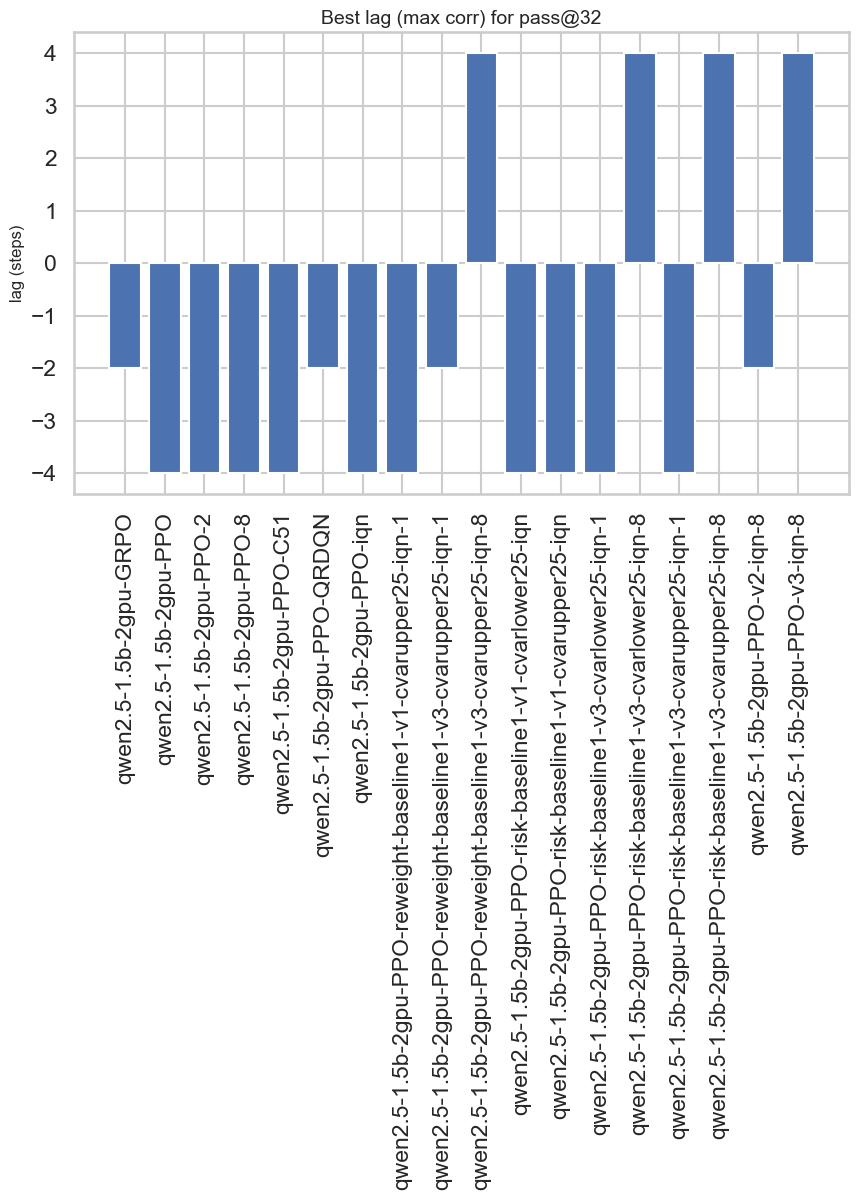

Generated 6 figures


In [4]:
# Plot 2: best lag per algorithm
for metric in metrics:
    sub = lagcorr[lagcorr["metric"] == metric]
    best = sub.loc[sub.groupby("algorithm")["corr"].idxmax()]
    new_fig(f"Best lag (max corr) for {metric}")
    plt.bar(best["algorithm"], best["lag"])
    plt.xticks(rotation=90)
    plt.ylabel("lag (steps)")
    plt.tight_layout()
    plt.show()

print(f"Generated {PLOT_COUNTER} figures")
